# K-Means DTW (DBA) — Clustering Test

End-to-end pipeline: load dataset → **KMeansDTW** (DBA centroid updates) → visualise.

Unlike K-Medoids, centroids here are *synthetic* time series produced by
**DTW Barycenter Averaging (DBA)**, not actual data points.
The representative track shown on the map is the *intra-cluster medoid*
(actual sample with minimum mean DTW distance to other cluster members).

> **Note**: `precomputed_matrix` is used only for `dtw_kmeans++` initialisation.
> Per-iteration assignment distances are recomputed from scratch.

## 1. Setup

In [1]:
import sys
sys.path.insert(0, r"f:\NCKH\Framework")

import os
import math
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap
from matplotlib.lines import Line2D

## 2. Load Dataset

In [2]:
from dtw_clustering.datasets import load_historical_tc

ds = load_historical_tc(min_points=5, filter_lon_0_180=True)
X_list = ds.tracks_raw  # List[np.ndarray (T_i, 2)]: [lat, lon]

print(f"Tracks loaded : {len(X_list)}")
print(f"Track lengths : min={ds.track_info.n_points.min()}  "
      f"median={ds.track_info.n_points.median():.0f}  "
      f"max={ds.track_info.n_points.max()}")
ds.track_info.head()

Tracks loaded : 1900
Track lengths : min=6  median=35  max=111


,StormID,StormName,n_points
0,5101,,10
1,5102,GEORGIA,37
2,5103,HOPE,36
3,5104,IRIS,66
4,5105,JOAN,44


## 3. DTW Distance Matrix

In [3]:
MATRIX_PATH = r"f:\NCKH\Framework\experiments\distance_matrix\DTW_matrix.npy"

if os.path.exists(MATRIX_PATH):
    D = np.load(MATRIX_PATH)
    print(f"Loaded precomputed DTW matrix  shape={D.shape}  dtype={D.dtype}")
else:
    print("Precomputed matrix not found — computing (several minutes)...")
    from dtw_clustering.models.classical import KMeansDTW
    _tmp = KMeansDTW(n_clusters=2, n_jobs=-1, random_state=0)
    _tmp.fit(X_list)
    D = _tmp.distance_matrix_
    del _tmp
    os.makedirs(os.path.dirname(MATRIX_PATH), exist_ok=True)
    np.save(MATRIX_PATH, D)
    print(f"Computed and saved  shape={D.shape}")

Loaded precomputed DTW matrix  shape=(1900, 1900)  dtype=float64


## 4. Fit KMeansDTW

In [4]:
from dtw_clustering.models.classical import KMeansDTW

N_CLUSTERS = 5

model = KMeansDTW(
    n_clusters=N_CLUSTERS,
    metric="dtw",
    init="dtw_kmeans++",
    max_iter=50,
    tol=0.0,
    dba_max_iter=20,
    n_jobs=-1,
    random_state=0,
)

# precomputed_matrix speeds up dtw_kmeans++ initialisation only;
# per-iteration assignment distances are recomputed from scratch.
t0 = time.perf_counter()
model.fit(X_list, precomputed_matrix=D)
elapsed = time.perf_counter() - t0

print(f"Fit time   : {elapsed:.2f}s")
print(f"Inertia    : {model.inertia_:.4f}")
print(f"Iterations : {model.n_iter_}")

Fit time   : 411.10s
Inertia    : 81214.4171
Iterations : 19


## 5. Results

In [5]:
def intra_cluster_medoid(labels, D, k):
    """Intra-cluster medoid: sample with min mean DTW distance to other members."""
    idx = np.where(labels == k)[0]
    if len(idx) == 1:
        return int(idx[0])
    D_sub = D[np.ix_(idx, idx)]
    return int(idx[np.argmin(D_sub.mean(axis=1))])

result = ds.track_info.copy()
result["cluster"] = model.labels_

sizes   = result.groupby("cluster").size().rename("n_tracks")
avg_len = result.groupby("cluster")["n_points"].mean().rename("avg_len").round(1)

print("=== Cluster sizes ===")
print(pd.concat([sizes, avg_len], axis=1).to_string())

print()
print("=== Representative tracks (intra-cluster medoids) ===")
print("  (DBA centroids are synthetic; representative = nearest actual sample)")
for k in range(N_CLUSTERS):
    rep = intra_cluster_medoid(model.labels_, D, k)
    row = ds.track_info.iloc[rep]
    print(f"  cluster={k}  idx={rep}  StormID={row.StormID}  "
          f"StormName={row.StormName:<12}  n_points={row.n_points}")

=== Cluster sizes ===
         n_tracks  avg_len
cluster                   
0             278     40.1
1             459     36.6
2             460     26.3
3             116     30.0
4             587     43.5

=== Representative tracks (intra-cluster medoids) ===
  (DBA centroids are synthetic; representative = nearest actual sample)
  cluster=0  idx=1137  StormID=9231  StormName=HUNT          n_points=32
  cluster=1  idx=923  StormID=8517  StormName=VAL           n_points=22
  cluster=2  idx=1689  StormID=1522  StormName=MUJIGAE       n_points=18
  cluster=3  idx=851  StormID=8220  StormName=LOLA          n_points=18
  cluster=4  idx=1506  StormID=720  StormName=FAXAI         n_points=17


## 6. Visualisation — Cluster Tracks on Map

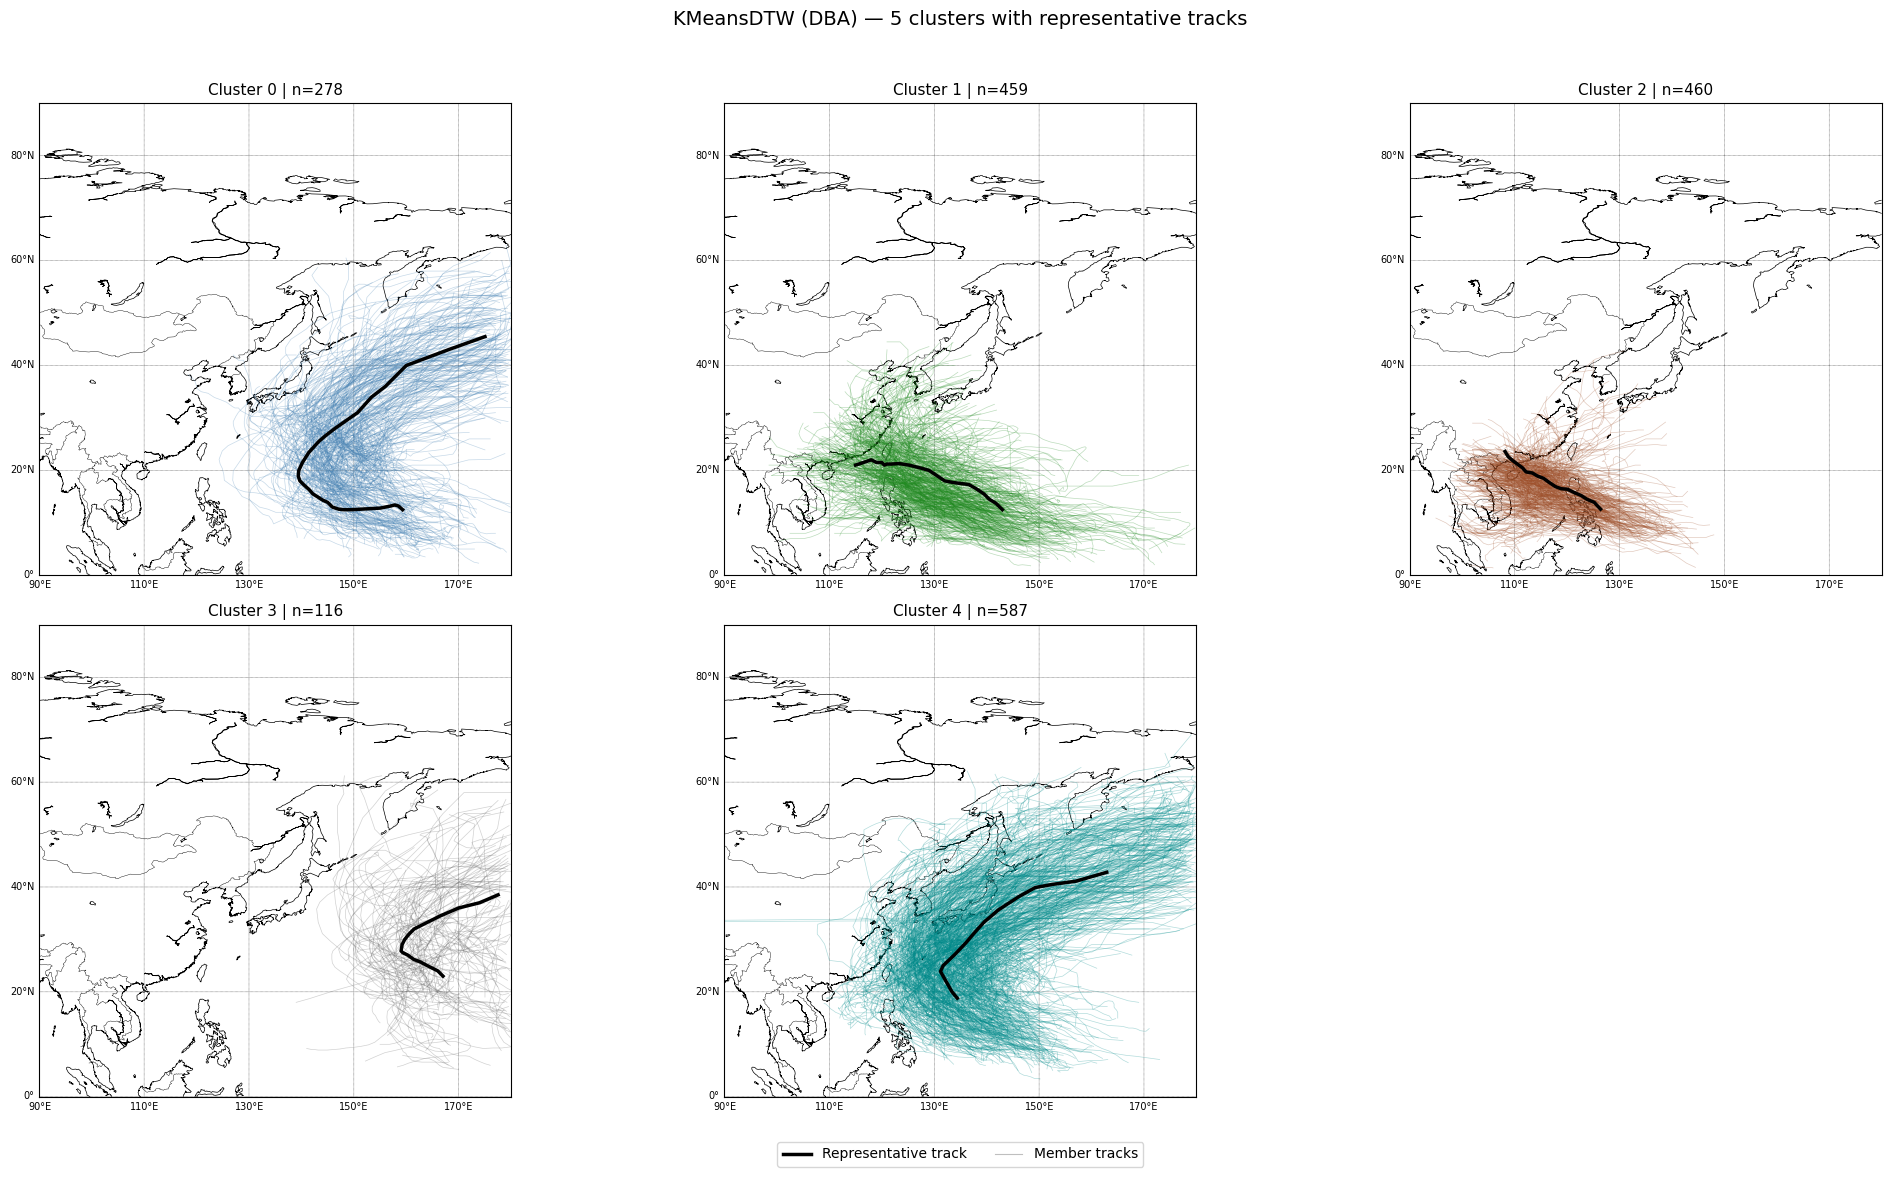

In [6]:
COLORS = ["steelblue", "forestgreen", "sienna", "dimgray", "darkcyan",
          "mediumpurple", "tomato", "goldenrod", "teal", "crimson"]

n_clusters = N_CLUSTERS
cluster_counts = np.bincount(model.labels_, minlength=n_clusters)

ncols = 3
nrows = math.ceil(n_clusters / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 6 * nrows), squeeze=False)
axes = axes.flatten()

for k in range(n_clusters):
    ax = axes[k]
    bm = Basemap(
        projection="cyl",
        llcrnrlat=0, urcrnrlat=90,
        llcrnrlon=90, urcrnrlon=180,
        resolution="l", ax=ax,
    )
    bm.drawcoastlines(linewidth=0.5)
    bm.drawcountries(linewidth=0.3)
    bm.drawparallels(range(0, 91, 20), labels=[1, 0, 0, 0], fontsize=7, linewidth=0.3)
    bm.drawmeridians(range(90, 181, 20), labels=[0, 0, 0, 1], fontsize=7, linewidth=0.3)

    color = COLORS[k % len(COLORS)]
    for idx in np.where(model.labels_ == k)[0]:
        track = ds.tracks_raw[idx]
        x, y = bm(track[:, 1], track[:, 0])
        ax.plot(x, y, color=color, alpha=0.3, linewidth=0.5)

    rep_idx = intra_cluster_medoid(model.labels_, D, k)
    rep = ds.tracks_raw[rep_idx]
    x, y = bm(rep[:, 1], rep[:, 0])
    ax.plot(x, y, color="black", linewidth=2.5, zorder=5)
    ax.set_title(f"Cluster {k} | n={cluster_counts[k]}", fontsize=11)

for ax in axes[n_clusters:]:
    ax.set_visible(False)

legend_elements = [
    Line2D([0], [0], color="black", linewidth=2.5, label="Representative track"),
    Line2D([0], [0], color="gray", alpha=0.5, linewidth=0.8, label="Member tracks"),
]
fig.legend(handles=legend_elements, loc="lower center", ncol=2, fontsize=10,
           bbox_to_anchor=(0.5, 0.01))
fig.suptitle(f"KMeansDTW (DBA) — {n_clusters} clusters with representative tracks",
             fontsize=14)
plt.tight_layout(rect=[0, 0.05, 1, 0.96])
plt.show()